In [ ]:
!pip install -q\
torch==2.7.1 \
torchvision==0.22.1 \
torchaudio==2.7.1 \
transformers==4.53.2 \
sentence-transformers==5.0.0 \
setfit==1.1.3 \
datasets==3.6.0 \
scikit-learn==1.7.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.2/470.2 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.

In [ ]:
# 1. Import dependencies
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import numpy as np
import random
import wandb

random.seed(42)
np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
train_data = {
    "text": [
        # --- NEWS (formal MSA/English) ---
        "عاجل: مجلس الوزراء يوافق على زيادة الحد الأدنى للأجور بداية الشهر القادم",
        "وزارة الداخلية تعلن عن حملة مرورية مكثفة في القاهرة الكبرى بداية من الغد",
        "الرئيس يستقبل نظيره الفرنسي غدًا لبحث ملفات التعاون الاقتصادي",
        "ارتفاع أسعار الذهب اليوم في السوق المصري بنسبة 2%",
        "البرلمان يوافق مبدئيًا على تعديلات قانون الإيجار القديم",
        "محافظة الإسكندرية تعلن حالة الطوارئ بسبب سوء الأحوال الجوية",
        "شاهدوا: انقطاع الكهرباء في عدة أحياء بالقاهرة بسبب أعمال الصيانة",
        "نتيجة الثانوية العامة تُعلن الأسبوع القادم بحسب وزارة التربية والتعليم",
        "ارتفاع درجات الحرارة غدًا ليصل لأكثر من 40 درجة في الصعيد",
        "البنك المركزي يرفع أسعار الفائدة بمقدار 1% في اجتماعه الأخير",
        "غرق عبارة قبالة سواحل الإسكندرية وإنقاذ جميع الركاب",
        "توقيع اتفاقية تعاون بين مصر والسعودية في مجال الطاقة المتجددة",
        "حريق كبير في أحد مصانع العاشر من رمضان.. لا إصابات حتى الآن",
        "اجتماع طارئ لمجلس الأمن القومي لبحث تطورات الحدود الشرقية",
        "قرار جمهوري جديد بتعيين محافظ جديد لمحافظة الجيزة",
        "ازدحام مروري خانق على طريق القاهرة الإسكندرية الصحراوي بسبب حادث",
        "إعلان نتيجة انتخابات نقابة الصحفيين رسميًا اليوم",
        "غلق جزئي لميدان التحرير بسبب أعمال تطوير الطرق",
        "الحكومة تعلن عن حزمة دعم جديدة لصغار المزارعين",
        "مصرع 3 أشخاص في حادث تصادم على الطريق الدائري",
        "BREAKING: Central bank raises interest rates by 50 basis points",
        "City council approves new metro line extension starting next year",
        "Heavy rainfall warning issued for the coastal region this weekend",
        "President to meet with EU leaders next week over trade talks",
        "Local elections results expected to be announced by Friday",
        "Massive traffic jam on the ring road after multi-car accident",
        "Ministry of Health confirms new vaccination campaign starting Monday",
        "Stock market dips 3% following unexpected inflation report",
        "Wildfire forces evacuation of several villages in the north",
        "New airport terminal officially opens to the public today",
        "Parliament votes to pass the new labor law amendments",
        "Power outage affects thousands of homes across the capital",
        "School exam results to be released next week, ministry says",
        "Flooding reported in several neighborhoods after storm overnight",
        "Government announces subsidy increase for small farmers",
        "Three injured in factory fire, cause still under investigation",
        "Currency exchange rate hits new record high this morning",
        "Public transport workers announce strike starting tomorrow",
        "New bridge construction project approved by city officials",
        "Emergency meeting called after border tensions escalate",
        # --- NEWS (casual register — same topic class, informal delivery) ---
        "لسه قريت إن الحكومة قررت تأجيل قرار رفع الأسعار للشهر الجاي",
        "حد شايف إن مباراة النهاردة اتلغت بسبب الجو السيء؟",
        "سمعت إن فيه تعديل جديد في قانون العمل هيتطبق من الأسبوع الجاي",
        "الأسهم نزلت بشكل غريب النهاردة، حد عارف السبب؟",
        "شكلها الانتخابات هتتأجل تاني حسب الأخبار اللي طالعة",
        "just read that they're finally opening the new subway line downtown",
        "did you hear the mayor resigned this morning? wild news",
        "apparently there's a strike planned for next week, saw it on the news",
        "so the interest rate hike is official now, just confirmed",
        "heard the airport's expanding, gonna add two new terminals",
        "وزارة الصحة أصدرت بيانًا رسميًا بخصوص انتشار فيروس جديد في بعض المحافظات",
        "الجهاز المركزي للتعبئة العامة والإحصاء يعلن ارتفاع معدل التضخم إلى 32%",
        "نادي الزمالك يعلن التعاقد مع مدرب جديد بعد اجتماع مجلس الإدارة",
        "الأمم المتحدة تدعو لعقد جلسة طارئة لمناقشة الأزمة الإنسانية",
        "وزير الخارجية يزور واشنطن الأسبوع المقبل لبحث ملفات التعاون الثنائي",
        "Reports say the merger between the two tech giants was just approved",
        "The football federation announced a new coach following last night's meeting",
        "UN officials call for emergency session over the ongoing crisis",
        "Foreign minister to visit Washington next week for bilateral talks",
        "Tech company shares surge after quarterly earnings beat expectations",
        "مصادر صحفية تؤكد استقالة رئيس مجلس الإدارة بعد الأزمة المالية الأخيرة",
        "ارتفاع كبير في معدلات البطالة حسب أحدث تقرير للبنك الدولي",
        "saw breaking news that flights got cancelled because of the storm",
        "just got an alert that schools are closed tomorrow due to weather",
        "الحكومة توافق على مد مهلة تقديم الإقرار الضريبي أسبوعين إضافيين",
        # --- HISTORICAL_SCIENTIFIC (formal MSA/English) ---
        "تم بناء الأهرامات في عهد الأسرة الرابعة الفرعونية منذ أكثر من 4500 عام",
        "اكتشاف مقبرة أثرية جديدة في الأقصر تعود لعصر الدولة الحديثة",
        "الماء يتكون من ذرتين هيدروجين وذرة أكسجين واحدة",
        "عملية التمثيل الضوئي هي كيف تحول النباتات ضوء الشمس إلى طاقة",
        "معركة عين جالوت كانت نقطة تحول تاريخية ضد المغول",
        "محمد علي باشا أسس مصر الحديثة في القرن التاسع عشر",
        "الضوء يسافر بسرعة تقارب 300 ألف كيلومتر في الثانية",
        "حجر رشيد ساعد العلماء على فك رموز الكتابة الهيروغليفية",
        "الدماغ البشري يحتوي على حوالي 86 مليار خلية عصبية",
        "صلاح الدين الأيوبي حرر بيت المقدس عام 1187 ميلاديًا",
        "تعاقب الفصول ناتج عن ميلان محور الأرض وليس بعدها عن الشمس",
        "مكتبة الإسكندرية القديمة كانت أعظم مركز للعلم في العالم القديم",
        "الديناصورات انقرضت منذ حوالي 66 مليون سنة",
        "ابن سينا يعتبر من أهم علماء الطب في العصور الوسطى",
        "الجاذبية الأرضية هي التي تجعل الأجسام تسقط نحو الأرض",
        "ثورة 1919 كانت من أهم أحداث التاريخ المصري الحديث",
        "خلايا الدم الحمراء تحمل الأكسجين إلى جميع أنحاء الجسم",
        "قناة السويس افتُتحت رسميًا عام 1869",
        "الذرة تتكون من بروتونات ونيوترونات وإلكترونات",
        "توت عنخ آمون كان من أشهر ملوك الأسرة الثامنة عشرة",
        "The Great Pyramid of Giza took an estimated 20 years to build",
        "Water molecules are held together by hydrogen bonds",
        "The Roman Empire fell in 476 AD after centuries of decline",
        "Photosynthesis converts carbon dioxide and water into glucose and oxygen",
        "Ancient Egyptians used the Nile's flooding cycle to predict harvests",
        "DNA carries the genetic instructions for all living organisms",
        "The Renaissance began in Italy in the 14th century",
        "Gravity causes objects to accelerate toward Earth at 9.8 m/s²",
        "The printing press was invented by Gutenberg around 1440",
        "Mitochondria are often called the powerhouse of the cell",
        "The Industrial Revolution transformed manufacturing in the 18th century",
        "Light behaves as both a particle and a wave",
        "The Rosetta Stone helped decode ancient Egyptian hieroglyphs",
        "Neurons communicate with each other through electrical signals",
        "The Ottoman Empire lasted over 600 years before its collapse",
        "Continental drift explains how continents slowly move over time",
        "The human genome contains roughly 3 billion base pairs",
        "The Suez Canal officially opened for navigation in 1869",
        "Volcanic eruptions can be caused by shifting tectonic plates",
        "The Library of Alexandria was one of the largest in the ancient world",
        # --- HISTORICAL_SCIENTIFIC (casual register — this is the key fix) ---
        "TIL that octopuses have three hearts, kind of insane",
        "just found out sharks existed before trees, mind blown",
        "لسه عارف إن الفراعنة كانوا بيستخدموا العسل كمادة حافظة للجثث",
        "حد يصدق إن أبو الهول اتبنى من غير رفع أي حجر من مكان تاني؟",
        "did you know the Eiffel Tower grows a few inches taller in summer due to heat expansion",
        "قرأت مقال عجيب عن إن الأخطبوط بيغير لون جلده حسب مزاجه",
        "fun fact: honey never spoils, archaeologists found 3000 year old honey still edible",
        "لسه فاكر لما اتعلمت إن صوت الديناصورات كان أقرب لصوت الطيور مش الزئير",
        "حاجة غريبة إن أينشتاين رفض منصب رئاسة إسرائيل لما عرضوه عليه",
        "just learned that Cleopatra lived closer in time to the moon landing than to the pyramids",
        "بصراحة معرفتش إن نابليون كان قصير الطول ده مجرد خرافة منتشرة",
        "did you know bananas are berries but strawberries technically aren't",
        "حد عارف إن أول كمبيوتر كان بحجم أوضة كاملة؟ تخيل",
        "TIL Vikings never actually wore horned helmets, that's a myth from operas",
        "لسه مصدوم إن عمر الكون حوالي 13.8 مليار سنة",
        "just read that the Great Wall of China isn't visible from space with the naked eye",
        "الحمض النووي الريبوزي منقوص الأكسجين (DNA) يحمل التعليمات الوراثية لكل الكائنات الحية",
        "معظم الكواكب في مجموعتنا الشمسية تدور حول الشمس في نفس الاتجاه تقريبًا",
        "The Black Death killed an estimated one-third of Europe's population in the 14th century",
        "Marie Curie was the first person to win Nobel Prizes in two different sciences",
        "بردية إيبرس القديمة تعتبر من أقدم الوثائق الطبية المعروفة في التاريخ",
        "العلماء اكتشفوا مؤخرًا أن الأخطبوطات قد تحلم أثناء النوم",
        "did you know the shortest war in history lasted only 38 minutes",
        "حد فاكر إن أول رسالة إلكترونية اتبعتت كانت سنة 1971؟",
        "Antarctica is technically the largest desert on Earth by area",
        # --- MEDICAL (formal MSA/casual Egyptian mix, original) ---
        "التدخين يزيد من خطر الإصابة بسرطان الرئة بشكل كبير",
        "شرب المياه بكثرة يساعد على تحسين وظائف الكلى",
        "أعراض السكري تشمل العطش الشديد وكثرة التبول",
        "لازم تاخد الفيتامين D عشان صحة العظام والمناعة",
        "ضغط الدم المرتفع ممكن يسبب مشاكل خطيرة في القلب",
        "النوم أقل من 6 ساعات يوميًا بيأثر سلبًا على المناعة",
        "الأطباء ينصحون بممارسة الرياضة 30 دقيقة يوميًا لصحة القلب",
        "نقص الحديد في الجسم بيسبب الأنيميا والتعب المستمر",
        "لقاح الإنفلونزا الموسمي متاح الآن في جميع المراكز الصحية",
        "الإفراط في تناول السكر مرتبط بزيادة خطر السمنة والسكري",
        "أعراض جلطة القلب تشمل ألم في الصدر وضيق في التنفس",
        "غسيل اليدين المستمر بيقلل من انتشار الأمراض المعدية",
        "فيتامين سي بيساعد في تقوية جهاز المناعة",
        "قلة شرب الماء ممكن تسبب حصوات في الكلى",
        "الرضاعة الطبيعية بتوفر مناعة طبيعية للطفل في الشهور الأولى",
        "الصداع النصفي ممكن يكون سببه التوتر أو قلة النوم",
        "فحص الثدي الدوري مهم جدًا للكشف المبكر عن السرطان",
        "الكوليسترول المرتفع من أهم أسباب أمراض الشرايين",
        "الأطفال محتاجين تطعيمات إجبارية في السنة الأولى من العمر",
        "الإجهاد النفسي المزمن بيأثر على صحة القلب والجهاز الهضمي",
        "Doctors recommend at least 30 minutes of exercise daily for heart health",
        "High blood pressure increases the risk of stroke and heart disease",
        "Vitamin D deficiency is linked to weakened bones and low immunity",
        "Symptoms of diabetes include excessive thirst and frequent urination",
        "Smoking significantly raises the risk of developing lung cancer",
        "Drinking enough water daily helps maintain healthy kidney function",
        "The flu vaccine is now available at all local health centers",
        "Iron deficiency can lead to anemia and constant fatigue",
        "Regular handwashing helps reduce the spread of infectious diseases",
        "Chronic stress can negatively affect heart and digestive health",
        "Breast cancer screening is important for early detection",
        "Children need mandatory vaccinations during their first year of life",
        "High cholesterol is a major risk factor for artery disease",
        "Migraines can be triggered by stress, dehydration, or lack of sleep",
        "Breastfeeding provides natural immunity to infants in early months",
        "Too much sugar intake is linked to obesity and type 2 diabetes",
        "Signs of a heart attack include chest pain and shortness of breath",
        "Getting less than 6 hours of sleep can weaken your immune system",
        "Vitamin C helps support and strengthen the immune system",
        "Doctors warn that dehydration can lead to kidney stones",
        # --- MEDICAL (more casual/personal-anecdote register) ---
        "just found out too much caffeine can actually mess with your sleep cycle long term",
        "لسه عرفت إن قلة النوم ممكن تأثر على تركيزك في الشغل بشكل واضح",
        "did you know stress can literally raise your blood pressure within minutes",
        "حد قالي إن الصيام المتقطع بيساعد في تنظيم مستوى السكر في الدم",
        "fun health fact: your body regenerates most of its cells within a decade or so",
        "بصراحة مكنتش عارف إن نقص فيتامين ب12 بيسبب تنميل في الإيدين",
        "just learned drinking water first thing in the morning helps kickstart metabolism",
        "لسه فاكر الدكتور قالي أهمية تقليل الملح عشان الضغط",
        "did you know sitting for too long every day is linked to heart problems",
        "حاسس إني لازم أزور طبيب أسنان، مش رايح من فترة طويلة",
        "just read that regular stretching can reduce the risk of injury during workouts",
        "أطباء الأعصاب ينصحون بتقليل وقت الشاشات قبل النوم لتحسين جودة النوم",
        "الإفراط في استخدام المضادات الحيوية قد يؤدي إلى مقاومة بكتيرية خطيرة",
        "Regular eye checkups can catch early signs of glaucoma before symptoms appear",
        "منظمة الصحة العالمية توصي بتناول خمس حصص من الخضروات والفواكه يوميًا",
        "دراسة حديثة تربط بين قلة التعرض لأشعة الشمس ونقص فيتامين د",
        "just found out that skipping breakfast regularly might affect your metabolism",
        "did you know your gut bacteria can actually influence your mood",
        "لسه حاسس بصداع من الصبح، ممكن يكون من قلة النوم أو الكافيين الزيادة",
        "Cardiologists recommend limiting saturated fat intake to protect heart health",
        "الأطفال الرضع محتاجين فحوصات دورية لمتابعة النمو والتطور الحركي",
        "just read an article saying probiotics can help with digestive issues",
        "قلة الحركة لفترات طويلة أثناء السفر ممكن تزود خطر تجلط الدم",
        "did you know your blood type can affect which mosquitoes bite you more",
        "حد عنده نصيحة لتقليل حساسية الجيوب الأنفية في فصل الربيع؟",
        # --- NON_NEWS (casual social-media register, original) ---
        "يا جماعة ايه احسن مكان بيعمل كشري في القاهرة؟ حد يرشحلي 🙏",
        "ههههه بجد الفيديو ده ضحكني اوي مش قادر 😂😂😂",
        "النهاردة يوم جميل جدًا الحمدلله ربنا يسعدكم يا رب ❤️",
        "حد عنده توصية لفيلم كويس على نتفليكس؟ زهقت من التاني",
        "صباح الخير يا أحلى ناس ✨ يومكم يكون مليان بركة",
        "خلصت الامتحانات أخيرا 🎉 مبسوطة جدًا النهاردة",
        "عايز أشتري لابتوب جديد حد عنده اقتراح؟ الميزانية محدودة شوية",
        "أفضل تطبيق لتتبع المصاريف ايه في رأيكم؟",
        "الجو حلو اوي النهارده يلا نروح البحر 🌊",
        "مين جرب الكافيه الجديد في مدينة نصر؟ يستاهل؟",
        "عيد ميلاد سعيد لأجمل صديقة في الدنيا 🎂💕",
        "حاسس اني محتاج أجازة بجد، الشغل تعبني الفترة دي",
        "بجد اللي بيقول القهوة مش بتفرق معايا ده مش عارف يعيش",
        "شكرا لكل اللي هنأني بعيد ميلادي، حبكم وصلني ❤️",
        "رأيي الشخصي إن الموسيقى الكلاسيكية مبالغ فيها شوية",
        "مين بيتابع المسلسل الجديد؟ الحلقة اللي فاتت كانت جامدة",
        "خصم 50% على كل المنتجات لفترة محدودة، متفوتوش الفرصة!",
        "بحب القطط اوي، عندي 3 في البيت وكل واحد شخصيته مختلفة",
        "جربت اليوجا النهاردة أول مرة وكانت تجربة حلوة",
        "مين عنده اقتراح لمكان جميل نقضي فيه ويكند؟",
        "Anyone have recommendations for a good coffee shop downtown?",
        "Lol this video literally made my whole day 😂",
        "Feeling so grateful today, life is good ❤️",
        "Just finished my exams finally!! So relieved 🎉",
        "Looking to buy a new laptop, any suggestions on a budget?",
        "What's the best app for tracking expenses these days?",
        "Weather is perfect today, definitely a beach day 🌊",
        "Anyone tried that new restaurant downtown? Worth it?",
        "Happy birthday to my best friend, love you so much 🎂",
        "Honestly feel like I really need a vacation right now",
        "I personally think classical music is a bit overrated tbh",
        "Who's watching the new show? Last episode was insane",
        "50% off everything this weekend only, don't miss out!",
        "I love cats so much, I have three and they're all so different",
        "Tried yoga for the first time today and it was amazing",
        "Anyone have suggestions for a nice weekend getaway spot?",
        "Just adopted a puppy and I'm the happiest person alive 🐶",
        "Can't believe how fast this year is flying by",
        "Rating my top 5 comfort foods, number one has to be pasta",
        "Does anyone else procrastinate this much or is it just me lol",
        # --- NON_NEWS (more neutral/formal-toned personal reflection — breaks the "formal = news/science" shortcut) ---
        "أعتقد أن العمل عن بُعد غيّر نظرة كثير من الناس لمفهوم التوازن بين الحياة والعمل",
        "من وجهة نظري، القراءة قبل النوم أفضل بكثير من متابعة الهاتف",
        "لاحظت مؤخرًا أنني أصبحت أفضل تنظيمًا لوقتي بعد أن بدأت أكتب قائمة مهام يومية",
        "I've come to realize that minimalism isn't about owning less, it's about intention",
        "Reflecting on this year, I think I finally understand what work-life balance really means to me",
        "بدأت أمارس المشي يوميًا وحسّيت إن مزاجي بقى أحسن بشكل ملحوظ",
        "قررت إني أاخد بريك من مواقع التواصل الاجتماعي لمدة أسبوع، حاسس إني محتاجه",
        "Started journaling every night and it's honestly helped me process things better",
        "حد جرب يشتغل من الكافيهات؟ حاسس إني بركز أكتر برا البيت",
        "بصراحة قررت أطبخ أكتر في البيت بدل ما أطلب أكل بره كل يوم",
        "I've been meaning to learn a new language, any suggestions on where to start?",
        "مين عنده تجربة مع تطبيقات تعلم اللغات؟ عايز رأيكم قبل ما أشترك",
        "Just switched to a new gym and honestly the vibe there is so much better",
        "حاسس إن السنة دي عدت بسرعة غريبة، مصدقش إننا في يوليو",
        "أفضل نصيحة اتقالتلي في شغلي كانت من مديري القديم، لسه فاكرها لحد دلوقتي",
        "Trying out a new morning routine, waking up an hour earlier has been a game changer",
        "زوري النهاردة معرض فني صغير في وسط البلد، لوحات جميلة جدًا",
        "I've started collecting vinyl records lately, it's such a satisfying hobby",
        "رأيي إن الأفلام القديمة فيها روح مش موجودة في الأفلام الحديثة",
        "Does anyone else feel like podcasts have replaced music for their daily commute?",
        "حابب أشارك تجربتي مع رجيم الكيتو، خسرت وزن كويس في شهرين",
        "Finally organized my closet, feels so satisfying to have everything in order",
        "بجد مبسوطة إني قررت أسيب شغلي القديم وأبدأ مشروعي الخاص",
        "Thinking about adopting a second cat, my current one seems a little lonely",
        "قاعد أفكر أرجع أدرس بعد الشغل، حد عنده نصيحة للي عدى بالتجربة دي؟",
    ],
    "label": (
        [0] * 65 +
        [1] * 65 +
        [2] * 65 +
        [3] * 65
    )
}

label_names = {0: "news", 1: "historical_scientific", 2: "medical", 3: "non_news"}

print(f'Total examples: {len(train_data["text"])}')
for i, name in label_names.items():
    print(f'  {name}: {train_data["label"].count(i)}')


Total examples: 260
  news: 65
  historical_scientific: 65
  medical: 65
  non_news: 65


In [ ]:
# Split into train/eval, stratified by label
indices = list(range(len(train_data["text"])))
train_idx, eval_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=train_data["label"]
)

def subset(idxs):
    return {
        "text": [train_data["text"][i] for i in idxs],
        "label": [train_data["label"][i] for i in idxs],
    }

train_dataset = Dataset.from_dict(subset(train_idx))
eval_dataset = Dataset.from_dict(subset(eval_idx))

print(f"Train size: {len(train_dataset)}, Eval size: {len(eval_dataset)}")

Train size: 208, Eval size: 52


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 4. Load multilingual base model
MODELS = {
    "MiniLM-L12": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "mDeBERTa-v3": "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    "mDeBERTa-v3-multi":"MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
}

In [ ]:
def compute_metrics(y_pred, y_test):
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    }

In [ ]:
trained_models = {}
eval_results = {}

for model_name, model_id in MODELS.items():

    print("=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    wandb.init(
        project="news-verification",
        name=model_name,
        config={
            "model": model_id,
            "epochs": 2,
            "batch_size": 32,
        },
      )

    model = SetFitModel.from_pretrained(model_id)

    args = TrainingArguments(
        batch_size=32,
        num_epochs=2,
        use_amp=True,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        metric=compute_metrics,
    )

    trainer.train()


    eval_preds = model.predict(eval_dataset["text"])
    eval_preds = [int(p) for p in eval_preds]
    eval_labels = list(eval_dataset["label"])

    acc = accuracy_score(eval_labels, eval_preds)
    macro_f1 = f1_score(eval_labels, eval_preds, average="macro")

    print(f"eval accuracy={acc:.4f}  macro_f1={macro_f1:.4f}")

    trained_models[model_name] = model
    eval_results[model_name] = {
        "preds": eval_preds,
        "labels": eval_labels,
        "accuracy": acc,
        "macro_f1": macro_f1,
    }

    wandb.log({"eval_accuracy": acc, "eval_macro_f1": macro_f1})
    wandb.finish()

Training MiniLM-L12


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/notebook/utils.py:280: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  return LooseVersion(v) >= LooseVersion(check)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authori

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

...

Step,Training Loss
1,0.343700
50,0.291600
100,0.194800
150,0.063300
200,0.003800
250,0.001300
300,0.001100
350,0.000800
400,0.000600
450,0.000500


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/py

eval accuracy=0.9423  macro_f1=0.9421


/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


eval_accuracy,▁
eval_macro_f1,▁
train/embedding_loss,█▇▅▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▅█▅▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▃▄▆████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁
eval_accuracy,0.94231
eval_macro_f1,0.94213
total_flos,0
train/embedding_loss,0.0002


In [ ]:
# ---------------------------------------------------------------------------
# Independent "hard" test set — written separately from train_data so it is a
# genuine held-out check, not just a random split of the same 160 examples.
# Includes harder cases: code-switching, ambiguous/borderline examples, and
# different registers than what appears in training.
# ---------------------------------------------------------------------------
hard_test_data = {
    "text": [
        # --- news (harder: informal register, code-switched, no obvious "breaking" cue) ---
        "سمعتوا ان في اجتماع مفاجئ للحكومة النهاردة بخصوص الأسعار؟",
        "Just saw on the news that parliament passed the new tax bill an hour ago",
        "في حريق كبير حصل قرب المصنع بس مفيش تفاصيل رسمية لسه",
        "Apparently the central bank meeting got moved up, market's already reacting",
        "الوزارة لسه ما اعلنتش نتيجة التحقيق بس متوقع تتاخر لبكرة",
        # --- historical_scientific (harder: casual tone, first-person framing) ---
        "قرأت مقال جامد عن ازاي الأهرامات اتبنت من غير معدات حديثة، حاجة تجنن",
        "Did you know mitochondria actually have their own separate DNA? blew my mind",
        "بصراحة درست تاريخ محمد علي في المدرسة بس دلوقتي فهمته أكتر",
        "TIL that light takes about 8 minutes to travel from the sun to earth",
        "حد يعرف ليه قناة السويس اتحفرت في المكان ده بالذات؟ فضولي اعرف",
        # --- medical (harder: personal/anecdotal framing, mixed with casual tone) ---
        "الدكتور قالي لازم اقلل الملح عشان ضغطي بقى عالي شوية",
        "Been trying to sleep 8 hours a night, apparently it really does help immunity",
        "حسيت بدوخة وصداع من امبارح، ممكن يكون سببه قلة الماء؟",
        "My doctor mentioned vitamin D deficiency is super common in people who work indoors",
        "بابا اتشخص بارتفاع الكوليسترول والدكتور طلب منه يمشي يوميا",
        # --- non_news (harder: opinionated/longer posts, no emojis, could look newsy) ---
        "شخصيا مش حاسس إن التطبيقات الجديدة دي بتضيف حاجة تستاهل، كلها نفس الفكرة",
        "Not gonna lie, this whole minimalist lifestyle trend feels kind of overrated to me",
        "قررت النهاردة اني اقلل من السوشيال ميديا شوية، حاسس إنه بياخد وقت كتير",
        "Been thinking about switching careers, anyone else made a big jump like that?",
        "مبسوط اني اخيرا رتبت أوضتي، كانت فوضى من كام اسبوع",
    ],
    "label": [
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1,
        2, 2, 2, 2, 2,
        3, 3, 3, 3, 3,
    ],
}

hard_test_dataset = Dataset.from_dict(hard_test_data)
print(f"Hard test set size: {len(hard_test_dataset)}")
for i, name in label_names.items():
    print(f"  {name}: {hard_test_data['label'].count(i)}")


Hard test set size: 20
  news: 5
  historical_scientific: 5
  medical: 5
  non_news: 5


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

hard_labels = list(hard_test_dataset["label"])

comparison_rows = []
hard_results = {}

for model_name, model in trained_models.items():
    hard_preds = model.predict(hard_test_dataset["text"])
    hard_preds = [int(p) for p in hard_preds]

    hard_acc = accuracy_score(hard_labels, hard_preds)
    hard_f1 = f1_score(hard_labels, hard_preds, average="macro")

    hard_results[model_name] = {
        "preds": hard_preds,
        "labels": hard_labels,
        "accuracy": hard_acc,
        "macro_f1": hard_f1,
    }

    comparison_rows.append({
        "model": model_name,
        "eval_accuracy": eval_results[model_name]["accuracy"],
        "eval_macro_f1": eval_results[model_name]["macro_f1"],
        "hard_test_accuracy": hard_acc,
        "hard_test_macro_f1": hard_f1,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("model")
print(comparison_df.round(4))

print("\nPer-class report on hard test set (per model):")
for model_name in trained_models:
    print(f"\n--- {model_name} ---")
    print(classification_report(
        hard_results[model_name]["labels"],
        hard_results[model_name]["preds"],
        target_names=[label_names[i] for i in sorted(label_names)],
        zero_division=0,
    ))


                   eval_accuracy  eval_macro_f1  hard_test_accuracy  \
model                                                                 
MiniLM-L12                0.9615         0.9613                0.90   
mDeBERTa-v3               0.8846         0.8811                0.85   
mDeBERTa-v3-multi         0.9423         0.9421                0.85   

                   hard_test_macro_f1  
model                                  
MiniLM-L12                     0.8958  
mDeBERTa-v3                    0.8352  
mDeBERTa-v3-multi              0.8520  

Per-class report on hard test set (per model):

--- MiniLM-L12 ---
                       precision    recall  f1-score   support

                 news       1.00      1.00      1.00         5
historical_scientific       1.00      0.60      0.75         5
              medical       1.00      1.00      1.00         5
             non_news       0.71      1.00      0.83         5

             accuracy                           0.90       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


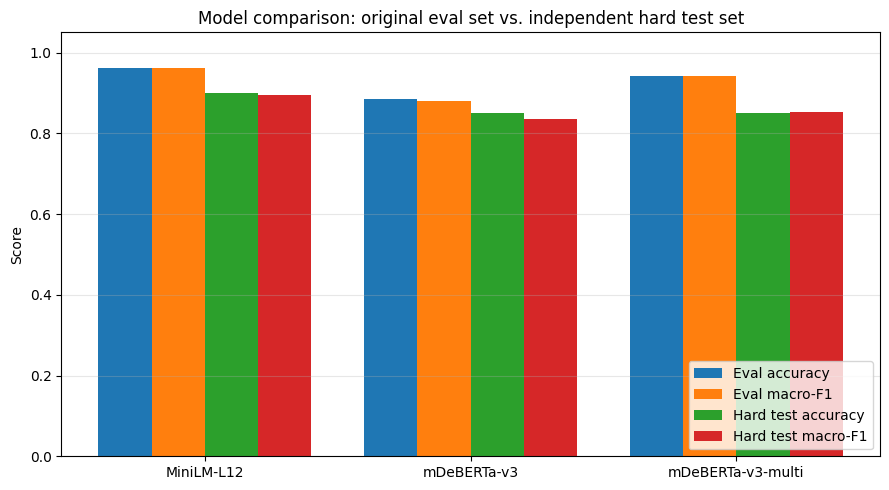

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models_list = list(comparison_df.index)
x = np.arange(len(models_list))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5*width, comparison_df["eval_accuracy"], width, label="Eval accuracy")
ax.bar(x - 0.5*width, comparison_df["eval_macro_f1"], width, label="Eval macro-F1")
ax.bar(x + 0.5*width, comparison_df["hard_test_accuracy"], width, label="Hard test accuracy")
ax.bar(x + 1.5*width, comparison_df["hard_test_macro_f1"], width, label="Hard test macro-F1")

ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model comparison: original eval set vs. independent hard test set")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()


Best model: MiniLM-L12
eval_accuracy         0.961538
eval_macro_f1         0.961310
hard_test_accuracy    0.900000
hard_test_macro_f1    0.895833
Name: MiniLM-L12, dtype: float64
Saved best model to ./best_model_MiniLM-L12


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


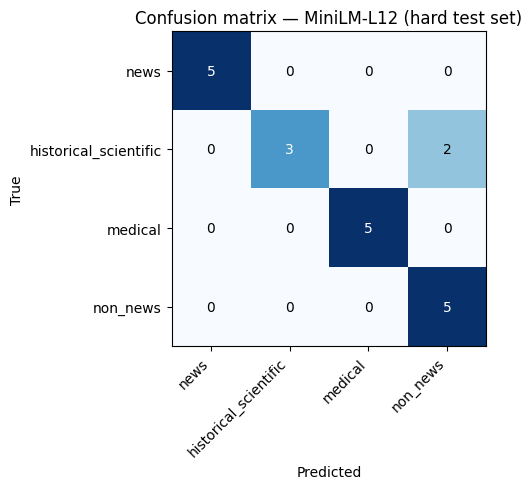

In [ ]:
best_model_name = comparison_df.sort_values(
    by=["hard_test_macro_f1", "hard_test_accuracy"], ascending=False
).index[0]

print(f"Best model: {best_model_name}")
print(comparison_df.loc[best_model_name])

best_model = trained_models[best_model_name]

save_dir = f"./best_model_{best_model_name}"
best_model.save_pretrained(save_dir)
print(f"Saved best model to {save_dir}")

# Confusion matrix for the winning model on the hard test set
cm = confusion_matrix(hard_results[best_model_name]["labels"], hard_results[best_model_name]["preds"])
class_names = [label_names[i] for i in sorted(label_names)]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {best_model_name} (hard test set)")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("best_model_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# Quick sanity check: load the saved best model and try it on brand-new
# sentences that appear in neither train_data nor hard_test_data.
from setfit import SetFitModel

loaded_model = SetFitModel.from_pretrained(save_dir)

sanity_examples = [
    "الحكومة أعلنت اليوم عن رفع أسعار الوقود بداية من الشهر القادم",
    "Scientists discovered a new exoplanet that might support liquid water",
    "حاسس اني عايز اجازة، الشغل تعبني الاسبوع ده",
    "My grandmother was just diagnosed with early-stage arthritis",
]

preds = loaded_model.predict(sanity_examples)
for text, pred in zip(sanity_examples, preds):
    print(f"[{label_names[int(pred)]:>20}]  {text}")

[                news]  الحكومة أعلنت اليوم عن رفع أسعار الوقود بداية من الشهر القادم
[historical_scientific]  Scientists discovered a new exoplanet that might support liquid water
[            non_news]  حاسس اني عايز اجازة، الشغل تعبني الاسبوع ده
[             medical]  My grandmother was just diagnosed with early-stage arthritis


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from huggingface_hub import login, create_repo

login()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
repo_name = "darck-12/news-classification-minilm"
create_repo(
    repo_id=repo_name,
    exist_ok=True
)


RepoUrl('https://huggingface.co/darck-12/news-classification-minilm', endpoint='https://huggingface.co', repo_type='model', repo_id='darck-12/news-classification-minilm')

In [ ]:
best_model.push_to_hub(
    repo_name,
    commit_message="Initial release"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:114: DeprecationWarning: hf_xet.upload_files() is deprecated. Use XetSession().new_upload_commit().start_upload_file() instead.
  return fn(*args, **kwargs)


  ...ion-minilm/tokenizer.json:   1%|1         |  178kB / 17.1MB            

  ...-minilm/model.safetensors:   0%|          |  552kB /  471MB            

  ...ion-minilm/model_head.pkl:   8%|7         | 1.00kB / 13.2kB            

CommitInfo(commit_url='https://huggingface.co/darck-12/news-classification-minilm/commit/a4476ede683451bf01d919964124850eefc510f2', commit_message='Initial release', commit_description='', oid='a4476ede683451bf01d919964124850eefc510f2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/darck-12/news-classification-minilm', endpoint='https://huggingface.co', repo_type='model', repo_id='darck-12/news-classification-minilm'), pr_revision=None, pr_num=None)

In [ ]:
from setfit import SetFitModel

model = SetFitModel.from_pretrained(repo_name)


config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

config_setfit.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model_head.pkl:   0%|          | 0.00/13.2k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
preds = model.predict(["الحكومة أعلنت اليوم عن رفع أسعار الوقود"])


tensor([0])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
preds

tensor([0])

In [ ]:
print(label_names[int(preds[0])])


news


In [ ]:
test_cases = {
    "TIL that octopuses have three hearts, kind of insane": "historical_scientific",
    "قرأت مقال عجيب عن إن الأخطبوط بيغير لون جلده حسب مزاجه": "historical_scientific",
    "بصراحة قررت أطبخ أكتر في البيت بدل ما أطلب أكل بره كل يوم": "non_news",
}
preds = model.predict(list(test_cases.keys()))
for (text, expected), pred in zip(test_cases.items(), preds):
    got = label_names[int(pred)]
    mark = "✓" if got == expected else "✗"
    print(f"{mark} expected={expected:22} got={got:22} | {text}")

✓ expected=historical_scientific  got=historical_scientific  | TIL that octopuses have three hearts, kind of insane
✓ expected=historical_scientific  got=historical_scientific  | قرأت مقال عجيب عن إن الأخطبوط بيغير لون جلده حسب مزاجه
✓ expected=non_news               got=non_news               | بصراحة قررت أطبخ أكتر في البيت بدل ما أطلب أكل بره كل يوم


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
